In [182]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
from scipy.stats import bootstrap
import matplotlib 
%matplotlib inline

In [183]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs w/o spike-ins 2 and 3
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']
# spike-in 1 is GATC

# cell lines w/o spike-ins 2 and 3; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 8)] + ['SK1_10'] + ['SK1_' + '{:0.0f}'.format(i) for i in range(12, 45)] # excluding 8 and 11
samples_3w_rag1 = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 8)] + ['SK1_10'] + ['SK1_' + '{:0.0f}'.format(i) for i in range(12, 25)] # excluding 8 and 11
samples_3w_f1 = ['SK1_' + '{:0.0f}'.format(i) for i in range(25, 45)] 
samples_2d = ['SK1_' + '{:0.0f}'.format(i) for i in [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]] + ['SK1_58_2', 'SK1_59_2', 'SK1_60_2']
samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]
samples_transplant = ['SK1_' + '{:0.0f}'.format(i) for i in [94, 95, 99] + [103, 104, 107] + [111, 112, 114]]
samples_all = samples_pre_inj + samples_in_vitro + samples_2d + samples_3w + samples_transplant

In [16]:
# reading the cell line couts for each sample
n_reads = pd.read_csv('../Data/cell-line-level/cell_line_counts_by_sample.csv', index_col=0)

In [179]:
# converting into # of cells
n_cells = pd.DataFrame([[x] + [0 for y in samples_3w + samples_2d] for x in clIDs], columns = ['clID'] + samples_3w + samples_2d).set_index(['clID'])

n_cells_spiked_in = 50000

for i in samples_3w + samples_2d:
    for j in clIDs:
        # df.loc[row, column]
        n_cells.loc[j, i] = n_reads.loc[j, i] * n_cells_spiked_in / n_reads.loc['GATC', i]

In [178]:
# bootstrapping fractions in 3w f1 and rag1 mice:

bootstrap_3w_f1 = {} # for each cell line: what, statistic, confidence intervals, bootstrapping distribution

for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    data = [] # for each cell line, cell fraction in each mouse 
    for i in samples_3w_f1:
        data.append(n_reads.loc[j, i] / sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]))
        
    out = bootstrap((data,), np.median, confidence_level=0.95, random_state=1, method='BCa', n_resamples=100000)
    bootstrap_3w_f1[j] = ['median, 0.95', np.median(data), out.confidence_interval, out.bootstrap_distribution]
    

/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:144: RuntimeWarning: invalid value encountered in double_scalars
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:97: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  warnings.warn(DegenerateDataWarning(msg))
/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:144: RuntimeWarning: invalid value encountered in double_scalars
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:97: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  warnings.warn(DegenerateDataWa

In [181]:
# bootstrapping fractions in 3w f1 and rag1 mice:

bootstrap_3w_rag1 = {} # for each cell line: what, statistic, confidence intervals, bootstrapping distribution

for j in clIDs:
    if j in ['GATC', 'AACC']: # skipping spike-in and mT4-2D
        continue
        
    data = [] # for each cell line, cell fraction in each mouse 
    for i in samples_3w_rag1:
        data.append(n_reads.loc[j, i] / sum(n_reads.loc[[x for x in clIDs if x not in ['GATC', 'AACC']], i]))
        
    out = bootstrap((data,), np.median, confidence_level=0.95, random_state=1, method='BCa', n_resamples=100000)
    bootstrap_3w_rag1[j] = ['median, 0.95', np.median(data), out.confidence_interval, out.bootstrap_distribution]
    

/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:144: RuntimeWarning: invalid value encountered in double_scalars
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/alyulina/Software/anaconda3/lib/python3.8/site-packages/scipy/stats/_resampling.py:97: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  warnings.warn(DegenerateDataWarning(msg))


In [151]:
# making the final table for Saswati:

table_3w = pd.DataFrame([[x] + [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] for x in clIDs if x not in ['GATC', 'AACC']], # excludinfg spike in and mT4-2D 
                        columns = ['clID'] + ['3w F1 med. # of cells', '3w F1 0.95 low CI for med. # of cells', '3w F1 0.95 high CI for med. # of cells', 
                                              '3w F1 med. # of cells / tot. # of cells / avg. pre-inj. frac.', '3w F1 0.95 low CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.', '3w F1 0.95 high CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.',
                                              '3w Rag1-/- med. # of cells', '3w Rag1-/- 0.95 low CI for med. # of cells', '3w Rag1-/- 0.95 high CI for med. # of cells', 
                                              '3w Rag1-/- med. # of cells / tot. # of cells / avg. pre-inj. frac.', '3w Rag1-/- 0.95 low CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.', '3w Rag1-/- 0.95 high CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.']).set_index(['clID'])


In [152]:
table_3w.head(0)

,3w F1 med. # of cells,3w F1 0.95 low CI for med. # of cells,3w F1 0.95 high CI for med. # of cells,3w F1 med. # of cells / tot. # of cells / avg. pre-inj. frac.,3w F1 0.95 low CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.,3w F1 0.95 high CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.,3w Rag1-/- med. # of cells,3w Rag1-/- 0.95 low CI for med. # of cells,3w Rag1-/- 0.95 high CI for med. # of cells,3w Rag1-/- med. # of cells / tot. # of cells / avg. pre-inj. frac.,3w Rag1-/- 0.95 low CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.,3w Rag1-/- 0.95 high CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.
clID,,,,,,,,,,,,


In [160]:
for j in clIDs:
    if j in ['GATC', 'AACC']:
        continue
        
    table_3w.loc[j, '3w F1 med. # of cells'] = bootstrap_3w_f1[j][1]
    table_3w.loc[j, '3w F1 0.95 low CI for med. # of cells'] = bootstrap_3w_f1[j][2][0]
    table_3w.loc[j, '3w F1 0.95 high CI for med. # of cells'] = bootstrap_3w_f1[j][2][1]
    
    table_3w.loc[j, '3w F1 med. # of cells / tot. # of cells / avg. pre-inj. frac.'] = bootstrap_3w_f1[j][1] / n_cells_3w_f1[j]
    table_3w.loc[j, '3w F1 0.95 low CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.'] = bootstrap_3w_f1[j][2][0] / n_cells_3w_f1[j]
    table_3w.loc[j, '3w F1 0.95 high CI for med. # of cells / tot. # of cells / avg. pre-inj. frac.'] = bootstrap_3w_f1[j][2][1] / n_cells_3w_f1[j]
    
    
    table_3w.loc[j, '3w Rag1-/- med. # of cells'] = bootstrap_3w_rag1[j][1]
    table_3w.loc[j, '3w Rag1-/- 0.95 low CI for med. # of cells'] = bootstrap_3w_rag1[j][2][0]
    table_3w.loc[j, '3w Rag1-/- 0.95 high CI for med. # of cells'] = bootstrap_3w_rag1[j][2][1]

In [163]:
sum(table_3w['3w F1 med. # of cells / tot. # of cells / avg. pre-inj. frac.'])

0.3606822164345991

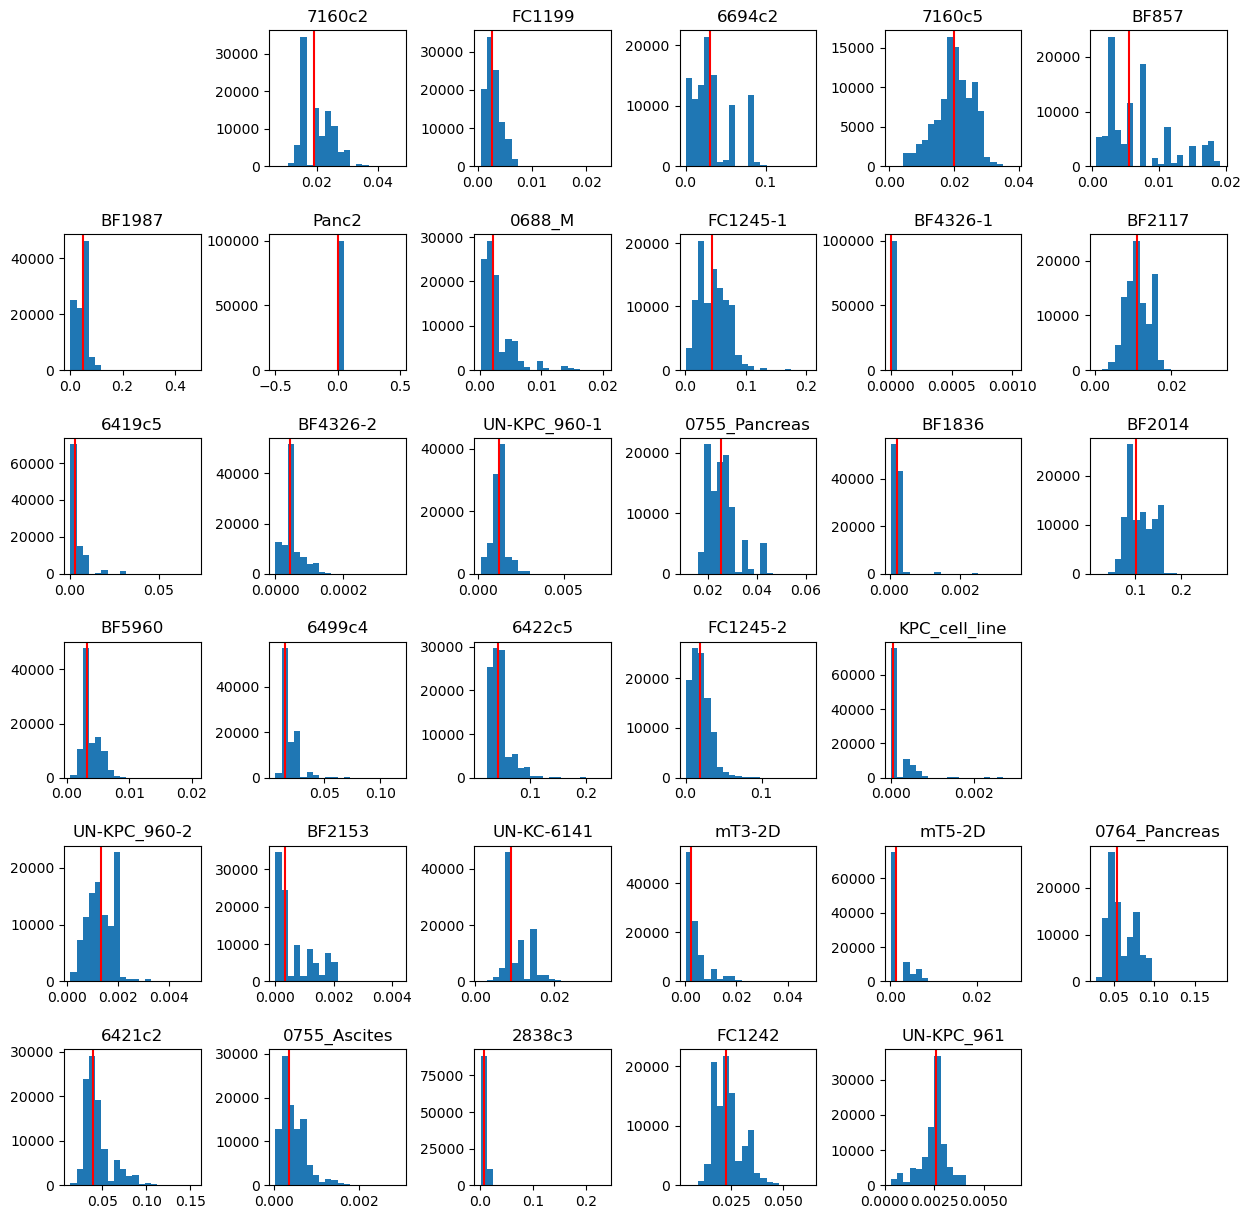

In [177]:
plt.figure(figsize=(15, 15))

grid = gridspec.GridSpec(ncols=6, nrows=6,
                         width_ratios=[1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1], hspace=0.5)

for count, j in enumerate(clIDs):
    if j in ['GATC', 'AACC']:
        continue
    
    plt.subplot(grid[count // 6, count % 6])
    plt.hist(bootstrap_3w_f1[j][3], bins=20)
    plt.axvline(bootstrap_3w_f1[j][1], color='red')
    plt.title(clID_dict[j])

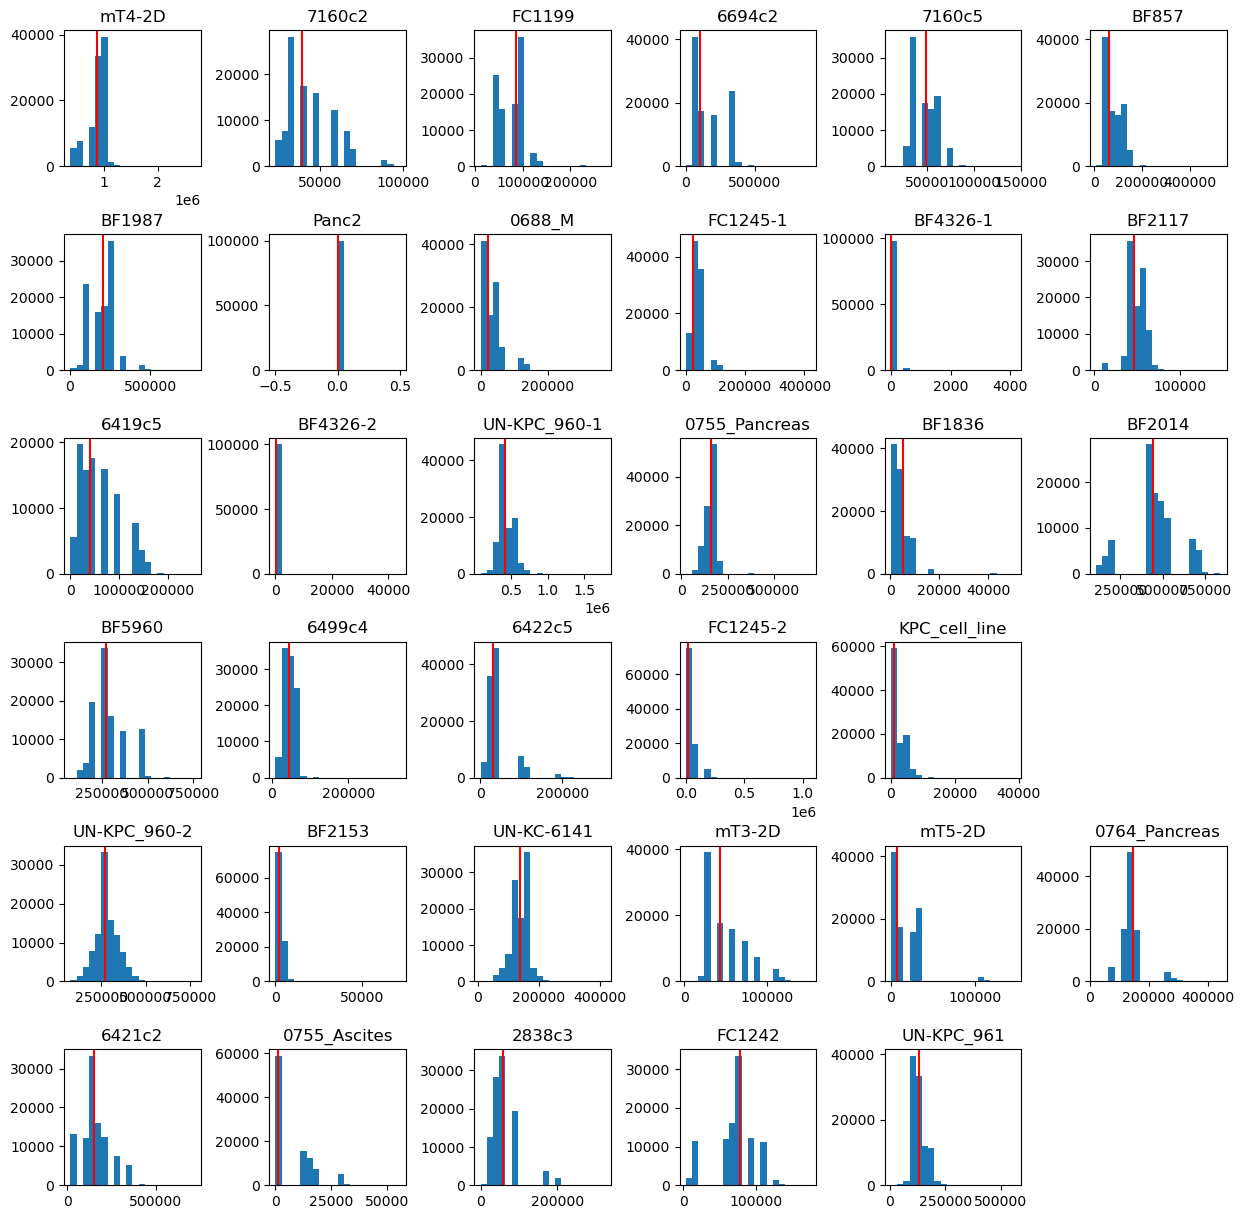

In [124]:
plt.figure(figsize=(15, 15))

grid = gridspec.GridSpec(ncols=6, nrows=6,
                         width_ratios=[1, 1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1, 1, 1, 1, 1], hspace=0.5)

for count, j in enumerate(clIDs):
    if j == 'GATC':
        continue
    
    plt.subplot(grid[count // 6, count % 6])
    plt.hist(bootstrap_3w_rag1[j][3], bins=20)
    plt.axvline(bootstrap_3w_rag1[j][1], color='red')
    plt.title(clID_dict[j])

In [2]:
data = [7, 9, 10, 10, 12, 14, 15, 16, 16, 17, 19, 20, 21, 21, 23]

In [4]:
data = (data,)

In [8]:
bootstrap_ci = bootstrap(data, np.median, confidence_level=0.95,
                         random_state=1, method='percentile')

In [9]:
print(bootstrap_ci.confidence_interval)

ConfidenceInterval(low=10.0, high=20.0)


In [74]:
bootstrap_ci

BootstrapResult(confidence_interval=ConfidenceInterval(low=10.0, high=20.0), bootstrap_distribution=array([16., 17., 16., ..., 15., 16., 14.]), standard_error=1.8805628317711005)